**Preprocessing**




In [14]:
from google.colab import drive
drive.mount("/content/drive")
base = "/content/drive/MyDrive"


Mounted at /content/drive


In [ ]:
with open ("test_set_me.csv", "r") as file:
  df_test = pd.read_csv(file)
  id = df_test["question"]
  clarity_label = df_test["clarity_label"]
  evasion_label = df_test["Label"]
  #print(clarity_label)
  #print(evasion_label)
#df_test.head()
print(df_test['Label'].value_counts())

Label
Explicit               78
General                72
Implicit               62
Dodging                50
Deflection             17
Declining to answer    14
Claims ignorance        8
Clarification           4
Partial/half-answer     3
Name: count, dtype: int64


In [ ]:
!python -m spacy download en_core_web_trf
!pip install wordfreq
!pip install -U sentence-transformers
from sentence_transformers import util, SentenceTransformer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.9/237.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 43.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 15.9 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5

In [2]:
import json
import re
import pandas as pd
import spacy
from collections import Counter
#nlp = spacy.load("en_core_web_trf")
from datasets import load_dataset
dataset = load_dataset("ailsntua/QEvasion")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

In [8]:
def get_data (datacollect, split):
  splied_data = datacollect[split]
  return splied_data
train_dataset = get_data(dataset, 'train')
test_dataset = get_data(dataset, 'test')
print(train_dataset)
#print(test_dataset)

Dataset({
    features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
    num_rows: 3448
})


In [17]:
df_train = train_dataset.to_pandas()
df_test = test_dataset.to_pandas()
labels = []
for _, row in df_train.iterrows():
    clarity_label = [row.get("clarity_label", "")]
    evasion_label = [row.get("evasion_label", "")]


    #l = [row["annotator1"], row["annotator2"], row["annotator3"]]
    #labels.append(max(set(l), key=labels.count))
with open ("train_set_me.csv", 'w') as f:
  df_train.to_csv(f)

In [ ]:
df_train = train_dataset.to_pandas()
df_test = test_dataset.to_pandas()
df_test.head()
# reset_index change the row to 'index'
df_train = df_train.reset_index()
df_test = df_test.reset_index()

# renaming 'id'
df_train = df_train.rename(columns={'index': 'id'})
df_test = df_test.rename(columns={'index': 'id'})


In [ ]:
with open ("test_set.csv", 'r') as f:
  df_test_acl = pd.read_csv(f)
df_test_acl.head()
print(df_test_acl.columns.tolist())


['Unnamed: 0', 'Interview Question', 'Interview Answer', 'Question', 'Annotator1', 'Annotator2', 'Annotator3']


In [ ]:
# checking the overlapping
overlap_mask = df_test['question'].isin(df_train['question'])
overlap_ids = df_test[overlap_mask]['Unnamed: 0'].tolist()
print(f"overlapping sample: {len(overlap_ids)}")
if len(overlap_ids) > 0:
    print(f"overlapped ID: {overlap_ids}")
    print(df_test[overlap_mask][['id', 'question_clean']])

In [ ]:
missing_mask = ~df_test_acl['Question'].isin(df_test['question'])
missing_ids = df_test_acl[missing_mask]['Unnamed: 0'].tolist()  # change 'Unnamed: 0'

print(f"HF dataset (df_test_acl): {len(df_test_acl)} item")
print(f"original dataset (df_test): {len(df_test)} item")
print(f"More than HF dataset: {len(missing_ids)}")
print(f"More ID: {missing_ids}")

df_test_acl[missing_mask]

In [ ]:
def extract_after_colon(text):
    if pd.isna(text):
        return text
    text = str(text)
    if ':' in text:
        return text.split(':', 1)[1].strip()
    else:
        return text.strip()

df_test_acl['Question_clean'] = df_test_acl['Question'].apply(extract_after_colon)

df_test['question_clean'] = df_test['question'].apply(extract_after_colon)

missing_mask = ~df_test_acl['Question_clean'].isin(df_test['question_clean'])
missing_ids = df_test_acl[missing_mask]['Unnamed: 0'].tolist()

print(f"after cleaned HF sample points: {len(missing_ids)}")
print(f"More sample points: {missing_ids}")

extra_samples = df_test_acl[missing_mask][['Unnamed: 0', 'Question', 'Question_clean']]
print("\nmore sample：")
print(extra_samples.to_string(index=False))

In [ ]:
# checking overlapping in Question section
common_questions = set(df_test['question']).intersection(set(df_test_acl['Question']))
print(f"same Question item: {len(common_questions)}")
print(f"only HF Question item: {len(set(df_test_acl['Question']) - set(df_test['question']))}")
print(f"only acl Question item: {len(set(df_test['question']) - set(df_test_acl['Question']))}")

common_df = df_test[df_test['question'].isin(common_questions)]
common_acl = df_test_acl[df_test_acl['Question'].isin(common_questions)]

if len(common_df) > 0 and len(common_acl) > 0:
    merged = common_df.merge(common_acl, left_on='question', right_on='Question', how='inner')
    print(f"\nID samne: {(merged['Unnamed: 0_x'] == merged['Unnamed: 0_y']).sum()}")
    print(f"ID different: {(merged['Unnamed: 0_x'] != merged['Unnamed: 0_y']).sum()}")

In [ ]:
print(df_test['multiple_questions'].value_counts())


multiple_questions
False    306
True       2
Name: count, dtype: int64


In [30]:
print(df_train['evasion_label'].value_counts())

evasion_label
Explicit               1052
Dodging                 706
Implicit                488
General                 386
Deflection              381
Declining to answer     145
Claims ignorance        119
Clarification            92
Partial/half-answer      79
Name: count, dtype: int64


In [ ]:
clarity_table = pd.crosstab(df_train['president'], df_train['evasion_label'], margins=True, margins_name='Total')
print(clarity_table)

evasion_label    Claims ignorance  Clarification  Declining to answer  \
president                                                               
Barack Obama                   22             28                   46   
Donald J. Trump                65             37                   54   
George W. Bush                 18             18                   26   
Joseph R. Biden                14              9                   19   
Total                         119             92                  145   

evasion_label    Deflection  Dodging  Explicit  General  Implicit  \
president                                                           
Barack Obama            104      234       226      145       182   
Donald J. Trump         146      266       432      139       160   
George W. Bush           88      136       245       70       103   
Joseph R. Biden          43       70       149       32        43   
Total                   381      706      1052      386       488   

evas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

evasion_strategies = [
    'Explicit', 'Declining to Answer', 'Generalization', 'Implicit',
    'Claims Ignorance', 'Clarification Request', 'Deflection',
    'Partial/Half-Answer', 'Dodging'
]

evasion_crosstab = pd.crosstab(
    df_train[df_train['evasion_label'].notna()]['president'],
    df_train[df_train['evasion_label'].notna()]['evasion_label'],
    normalize='index' 
) * 100

for strategy in evasion_strategies:
    if strategy not in evasion_crosstab.columns:
        evasion_crosstab[strategy] = 0

evasion_crosstab = evasion_crosstab[evasion_strategies]

print("\n" + "=" * 60)
print("=" * 60)
print(evasion_crosstab.round(1))


In [ ]:
k = df_train[["multiple_questions"]]
print(k)
for index, row in k.iterrows():
  if row['multiple_questions'] == True:
    print(f"index {index}: {row['multiple_questions']}")

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,5,"Q. What about the redline, sir?","Well, the world has made it clear that these t...",None,None,Inquiring about the status or information reg...,None,Dodging,General,Dodging,False,False,True,0,Ambivalent,
1,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,2,Q. Will you invite them to the White House to ...,I think that anytime and anyplace that they ar...,None,None,Will you invite them to the White House to neg...,None,Deflection,General,General,False,False,False,1,Ambivalent,
2,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,1,"Q. Harsh. Mr. President, Japan has dropped the...",I think that the purpose of the U.N. Security ...,None,None,Why was it necessary for Japan to drop the thr...,None,Explicit,Implicit,Implicit,False,False,False,2,Ambivalent,
3,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,2,Q. The Lebanese Prime Minister is demanding a ...,I'll let Condi talk about the details of what ...,None,None,When will we see this resolution?,None,Explicit,General,General,False,False,False,3,Ambivalent,
4,None,None,None,https://www.presidency.ucsb.edu/documents/the-...,7,"Q. Thank you, Mr. President. Back on Iraq, a g...","No, I don't consider it a credible report; nei...",None,None,Updating the figure of Iraqi deaths,None,Dodging,Implicit,Dodging,False,False,True,4,Ambivalent,


In [ ]:
from nltk.corpus import words
import nltk
nltk.download('words')
!pip install pyenchant -i https://pypi.tuna.tsinghua.edu.cn/simple
!apt-get update && apt-get install -y libenchant-2-2
import enchant
from enchant.checker import SpellChecker

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 596.9 kB/s eta 0:00:00
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,482 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,980 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:

In [ ]:
def word_correction(text, language, dictionary, ignore, manual):
  chkr = SpellChecker(language)
  chkr.set_text(text)
  changed_word = []
  for err in chkr:
    #print(err.word)
    if err.word in ignore:
      continue
    if err.word in manual.keys():
      word = manual[err.word]
      err.replace(word)
      continue
    suggested = dictionary.suggest(err.word)
    #print(suggested)
    suggested_word = [s for s in suggested if ' ' in s]

    if suggested_word:
      correction = suggested_word[0]
      changed_word.append(f"changed word: '{err.word}' -> '{correction}'")
      err.replace(correction)  # change directly based on checker

  corrected_text = chkr.get_text()
  return changed_word, corrected_text

language = "en_US"
dictionary = enchant.Dict(language)
text = " Helloworld! This is  funny thehe spokescountry /[]$&*()!@#$%^ I. /we seemsand"
ignore_tokens = {'counteroffensives', 'Abizaid','spokescountry', 'ultitely', 'rgue', 'NATOization', 'Vietn', 'uninsurance', 'ttend', 'dynis', 'nrrow', 'debtes', 'disencounters', 'Pcific', 'lameduck', 'Kukec', 'linkge', 'specificlly', 'honorbound', 'Crper', 'debting', 'resistnt', 'surefootedly', 'unrstands', 'narcotraffickers', 'prties', 'nontariff', 'onitor', 'regultio', 'essge', 'demarched', 'unrstanding', 'damageable', 'learship', 'itAuvelia', 'triment', 'Zengerle', 'lrgest', 'rguent', 'Bagnal', 'Sentors', 'ission', 'especilly', 'trde', 'Mandelas', 'ctully', 'pinful', 'bureaucratese', 'triffs', 'lwys', 'Eilperin', 'Schumers', 'opiners', 'pproch', 'antihumanitarian', 'legitite', 'pying', 'Madhani', 'proote', 'trafficants', 'rther', 'sying', 'probles', 'Runningen', 'reevaluations', 'underresourced', 'Afghn', 'itiveness', 'historiclly', 'Takatsuka', 'outcoes', 'Dorning', 'Mozgovaya', 'soething', 'Talev', 'COVAX', 'cochaired', 'contined', 'micromanages', 'landslided', 'reiterte', 'unrstand', 'PGII', 'Trns', 'Ohito', 'Suppelsa', 'Sunnyland', 'Groppe', 'Goler', 'JPOA', 'wnted', 'emboln', 'integrtio', 'denuke', 'colluder', 'exple', 'frnkly', 'nonbanking', 'deconflict', 'coresponsibility', 'Sadrists', 'familialy', 'woen', 'rtify', 'individul', 'Ignoti', 'confired', 'Elsisi', 'noncorruption', 'WFLD', 'resolvement', 'rdenas', 'locationally', 'uble', 'fstest', 'Presint', 'plns', 'coplints', 'nonmonetary', 'bups', 'reltively', 'ualified', 'soeties', 'engging', 'monoeconomy', 'Ledgett', 'cobt', 'nontariffed', 'reprioritizing', 'Labradores', 'prepred', 'coopertion', 'hrsher', 'stnd', 'trding', 'Liasson', 'budgeteers', 'Finlly', 'trgeting', 'unrstood', 'Cantarell', 'Intracostal', 'coitents', 'Entendio', 'engge', 'nipulted', 'greeent', 'Sttes', 'sustining', 'pageversus', 'semiobligation', 'ropelines', 'pssed', 'CDRI', 'halfglass', 'lredy', 'Wallsten', 'ballistical', 'shortfallings', 'wges', 'overclassify', 'Zelenskyy', 'uestion', 'antidevelopment', 'narcotrafficking', 'Bidenomics', 'ttention', 'sults', 'denuking', 'signl', 'pltfor', 'Colobin', 'tariffing', 'Aericn', 'enforceble', 'stcentury', 'decdes', 'dvnce', 'unniable', 'Talibanization', 'understnding', 'Hving', 'uemener', 'Enjeti', 'photoline', 'exctly', 'Rabium', 'nonlasting', 'Cartillier', 'Gerstenzang', 'significnt', 'progrowth', 'resynchronize', 'econoic', 'Foisy', 'Jansing', 'utul', 'plotsor', 'semicomplicated', 'Thomma', 'Aeric', 'Secretry', 'Petruni', 'Mnsur', 'enorous', 'Baathification', 'ipose', 'anticyclic', 'supercommittee', 'cyberstrength', 'Alsprin', 'contrst', 'Browder', 'Globlo', 'txes', 'lbor', 'ultiple', 'rejectionists', 'lifesavings', 'rket', 'ilitry', 'coing', 'Vietnese', 'counterreactions', 'Federl', 'pennt', 'precandidates', 'politicl', 'termined', 'EFPs', 'tlks', 'Dovere', 'Bilbassy', 'Tlibn', 'Pnnin', 'counterterroris', 'Imaichi', 'Saddamists', 'reencountering', 'intin', 'potentilly', 'opertions', 'trining'}
manul_change = {'seemsand':'seems and', 'monthsis':'months is', 'goand':'go and','economistsand':'economists and','soldiersand':'soldiers and','theand':'the and', 'intoA':'into A', 'Ifor':'I for', 'progressivesis':'progressives is' ,'Ihe':'I he','nowallows':'now allows', 'ISILThe':'ISIL The', 'themAnd':'them And'}
change, corrected = word_correction(text, language, dictionary, ignore_tokens, manul_change)
print(corrected)
'''for index, row in k.iterrows():
    print(f"index {index}: {row['interview_answer']}")
    change, corrected = word_correction(row['interview_answer'], language, dictionary, ignore_tokens)
    print(change)
    print(f"after_modified: {corrected}")'''

 Hello world! This is  funny the he spokescountry /[]$&*()!@#$%^ I. /we seems and


'for index, row in k.iterrows():\n    print(f"index {index}: {row[\'interview_answer\']}")\n    change, corrected = word_correction(row[\'interview_answer\'], language, dictionary, ignore_tokens)\n    print(change)\n    print(f"after_modified: {corrected}")'

In [ ]:
def clean_text(text: str) -> str:
    text = (text or "").strip()

    # remove [] tokens
    text = re.sub(r"\s*\[\]\s*", " ", text)

    # lower->Upper boundary insert space (e.g., "lookChina" -> "look China")
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)

    # normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
def get_sent(text):
  doc = nlp(text)
  sents = [sent.text.strip() for sent in doc.sents]
  return sents

print(get_sent("Well, I'm going to let the President answer the second part of that question But, as you know, the whole concept of that came up perhaps a little bit before, but it came out as a reason why the Democrats lost an election, which, frankly, they should have been able to win, because the electoral college is much more advantageous for Democrats, as you know, than it is to Republicans We won the electoral college by a lot—306 to 223, I believe And that was a well-fought—that was a well-fought battle We did a great jobAnd, frankly, I'm going to let the President speak to the second part of your question But just to say it one time again, and I say it all the time: There was no collusion I didn't know the President There was nobody to collude with There was no collusion with the campaign And every time you hear all of these—you know, 12 and 14—it's stuff that has nothing to do—and frankly, they admit, these are not people involved in the campaign But to the average reader out there, they're saying, Well, maybe that does It doesn't And even the people involved, some perhaps told mis-stories or, though in one case, the FBI said there was no lie There was no lie Somebody else said there wasWe ran a brilliant campaign, and that's why I'm President Thank you As to who is to be believed and to who is not to be believed, you can trust no one, if you take this Where did you get this idea that President Trump trusts me or I trust him? He defends the interests of the United States of America, and I do defend the interests of the Russian FederationWe do have interests that are common We are looking for points of contact There are issues where our postures diverge, and we are looking for ways to reconcile our differences; how to make our effort more meaningfulWe should not proceed from the immediate political interests that guide certain political powers in our countries We should be guided by facts Could you name a single fact that would definitively prove the collusion? This is utter nonsense, just like the President recently mentionedYes, the public at large in the United States had a certain perceived opinion of the candidates during the campaign, but there's nothing particularly extraordinary about it That's the usual thing President Trump, when he was a candidate, he mentioned the need to restore the Russia-US relationship, and it's clear that a certain part of American society felt sympathetic about it, and different people could express their sympathy in different ways But isn't that natural? Isn't it natural to be sympathetic towards a person who is willing to restore the relationship with our country, who wants to work with us?We heard the accusations about the Concord country Well, as far as I know, this company hired American lawyers And the accusations doesn't—doesn't have a fighting chance in the American courts So there's no evidence when it comes to the actual facts So we have to be guided by facts and not by rumorsNow, let's get back to the issue of these 12 alleged intelligence officers of Russia I don't know the full extent of the situation, but the President Trump mentioned this issue, and I will look into itSo far, I can say the following, the things that—off the top of my head: We have an acting—an existing agreement between the United States of America and the Russian Federation, an existing treaty that dates back to 1999, the Mutual Assistance on Criminal Cases This treaty is in full effect It works quite efficientlyOn average, we initiate about a hundred, hundred and fifty criminal cases upon request from foreign states For instance, the last year, there was one extradition case, upon the request, sent by the United States So this treaty has specific legal proceduresWe can offer that the appropriate commission headed by Special Attorney Mueller—he can use this treaty as a solid foundation, and send a formal, an official request to us so that we would interrogate—we would hold the questioning of these individuals who he believes are privy to some crimes And our law enforcement are perfectly able to do this questioning and send the appropriate materials to the United StatesMoreover, we can meet you halfway; we can make another step We can actually permit official representatives of the United States, including the members of this very commission headed by Mr Mueller—we can let them into the country and they will be present at this questioningBut in this case, there is another condition This kind of effort should be a mutual one Then we would expect that the Americans would reciprocate, and they would question officials, including the officers of law enforcement and intelligence services of the United States whom we believe are—who have something to do with illegal actions on the territory of Russia, and we have to request the presence of our law enforcementFor instance, we can bring up the—Mr Browder in this particular case Business associates of Mr Browder have earned over $1½ billion in Russia They never paid any taxes, neither in Russia nor in the United States, and yet the money escaped the country They were transferred to the United States They sent a huge amount of money—400 million—as a contribution to the campaign of Hillary Clinton Well, that's their personal case It might have been legal, the contribution itself, but the way the money was earned was illegalSo we have a solid reason to believe that some intelligence officers accompanied and guided these transactions So we have an interest of questioning them We can—that could be a first step, and we can also extend it Options abound, and they all can be found in an appropriate legal framework"))
print(get_sent("Hello world This is a test How are you Yes The political doesn't really help Greeting to you"))

["Well, I'm going to let the President answer the second part of that question But, as you know, the whole concept of that came up perhaps a little bit before, but it came out as a reason why the Democrats lost an election, which, frankly, they should have been able to win, because the electoral college is much more advantageous for Democrats, as you know, than it is to Republicans", "We won the electoral college by a lot—306 to 223, I believe And that was a well-fought—that was a well-fought battle We did a great jobAnd, frankly, I'm going to let the President speak to the second part of your question But just to say it one time again, and I say it all the time: There was no collusion I didn't know the President There was nobody to collude with", "There was no collusion with the campaign And every time you hear all of these—you know, 12 and 14—it's stuff that has nothing to do—and frankly, they admit, these are not people involved in the campaign", "But to the average reader out there

In [ ]:
import json

def create_jsonl_with_logs(dataset, language, dictionary, out_path, log_path, ignored, manual):
  with open(out_path, "w", encoding="utf-8") as f_data, \
    open(log_path, "w", encoding="utf-8") as f_log:

      for id in range(len(dataset)):
        item = dataset[id]
        answer = item.get("interview_answer") or ""
        changed_word, corrected_text = word_correction(answer, language, dictionary, ignored, manual)
        cleaned_answer = clean_text(corrected_text)

        obj = {"id": int(id),"interview_question":item.get("interview_question"),
               "question": item.get("question"),
               "answer": cleaned_answer,
               "sentenced_answer": get_sent(cleaned_answer),
               "clarity_label": item.get("clarity_label"),
               "evasion_label": item.get("evasion_label"),}
        f_data.write(json.dumps(obj, ensure_ascii=False) + "\n")

        log_obj = {"id": int(id),"before_answer": answer,"after_answer": corrected_text,"changes": changed_word}
        f_log.write(json.dumps(log_obj, ensure_ascii=False) + "\n")

  return out_path, log_path


ignore_tokens = {'counteroffensives',"Anbar's",'antiballistic','roadmap','incent','subregion','subregional','Mieke','Merkel','Paks','Cordray','subchapter','PEPFAR','havent','Heres','youre','werent','themself','Hutcheson','suiciders','kidnaped','Fletch','Faso','whomp','kidnaping','frontlines','Paso','Hillman',"Hillman's",'Abizaid','PEOC','deployable','Maliki','Siniora','leaker','Qaida','Anbar','Keil','Dinan','Prodi','biodiesel','Zarqawi','homefront','Caren','reauthorization','Quijano','Zal','Chertoff','powerplants','Sao','prospection','paramilitarism','DAS','narco','IG','NGOs','Celso','CODEL','ISAF','Labour','Gleneagles','Bolten','quos','ians','AMBO','Kosovars','Yi','Ramzi','al','Zawahiri','modus',"Maliki's",'Crocker','Malveaux','Anbar','PRTs','Maliki','Caren','Diyala','Anbar', 'Mohammed','NIE','Ahmadi','Condi','Abdallah','SCHIP','ANWR','Jintao','Kufuor','wellbeing','MCA',"Condi's",'Ramallah','PTSD',"Crocker's",'Knoller','Caren','homeownership','Blackwater',"Jintao's","d'etat","IG",'transformative','PKK','Kosovo','Il','Quijano',"Plante's",'PRI','PRD','IFE','ter','Sochi','Teo','reasonability','noncorrupt','tradeoffs','Programme','Nico','Eggen','ANWR','switchgrasses','reimposition','midsized','Siniora','capita','CAFTA','frontrunner','GSEs','Condi','Fayyad','ANWR','IAEA','Kosovo','ANSA','ly','IAEA','multilateralism','ANWR','delisting','Jeddah','transformative','Cowen','lears','Dokdo','ANWR','Eggen','openminded','Aww','FISA','overwatch','ese','Danforth','Ki','Paulson','cid','RCN','Caracol','FARC','provid','al','Huffington','Zakaria',"Hamas's", 'Hamas','Gitmo','hearted','AIG','Showell','AFP','Hamas','Elkhart','Crocker','CENTCOM','Zardari','Qaida','servicemembers','ians','underinsured','Tamiflu', 'ramped','Knoller','Pigford','multiethnic','Lagarde','CEOs','biodiesel','flatlined','MedPAC','AARP','Koff','Corriere','della','Lockerbie','Landale','ITAR','Macarena','MMS','AFP',"Gilani's",'Gilani','videoconference','speeded','ASEAN','flashpoint','Ministership','freefall','latelies','jumpstart','Cobell','ian','del','Bretton','Sanaa','posttraumatic','Qaida','Ambinder','Bowles','Condon','Speakership','maximalist','DOMA','Sciutto','ATF','UNIFIL','Schuman','De','underperforming','Dodd','trendlines','decisionmaking','Plante','dependant','relitigating','sed','Abadi',"Snowden's",'handholding','Arne','sarin',"Asad's",'drawdown','ns','vis','DACA','Mattis','Kuan','Tillerson','biofuels','São','Lores','Ramadi','Yellin','OSCE','AAP','DOJ','Cordes','AQAP','Chicagoans','san','Shimbun','SMEs','capita','NPT','responders','Ramstein','Un','Watertown', 'Fenway', 'Newtown', 'El', 'Costa','Kofi','Annan','Zardari','ISAF','Collinson','Norah','Qaida','Gillard','NPT','capita','IAEA', 'Hu','FTA','OPCON','OSCE','FISA','underfunding','Calmes','seatbelt','Rampton','Knoller','Leone','Snowden','FISC','failsafe','ACA','Ashton','counterproliferation','sizeable','Keane','Flacco','FATA','Jeh','Ideon','ECOWAS','operationalize','pre','ISAF','sectoral','APEC','cetera','Mattingly','timeframe',"t's","i's",'CENTCOM','APEC','nondefense','cyber','nonstate','nonfunctioning','Westgate','Fordow','intentioned','Abadi','Nedra','Anbar','ramped','blowback','se','Haram','mentorship','ASEAN','Najib','reprioritize','topline',"ISIL's",'Counterterrorism','mindboggling','FEMA',"Brexit's",'Turnberry','WikiLeaks','DNC','Anastasiadis','Univision','Knoller','decisionmaker','offshored','strivers','likeable','hyperpartisan','Asad','Gardiner','ISIL','pushback','overzealousness','brandnew','confliction','Idlib','interagency','sizeable','outmanned','Asad',"Asad's",'Sirte','Mediacorp','rebalancing','countermessage','ASEAN','Sino','FOIA','nonstate','prt','pst','nd','Nuber','pst','coes','llow','onetry','clis','ters','unifor','hnd','ung','ebers','ny',"hven't",'wy','hrd','clis','ters', 'Cn','Oky','lso','ebers','ny', 'coes','ce','ded','dy','del','soe','Nuber','dels','hs','del','lso','ters','unifor','wr','ny','Bretton','counterterrorism','Winfield','IAEA','hed','hs','ws','nd','wr','ke','ung','Labour','Gitmo','rebalance','counterterrorism','multimillion','ASEAN','Minh','ers','OECD','alltime','Warmbier','Mnuchin','Westwood','amongst','hydropower','intel','UNSC','Vitali','IIA','Marino','Bannon','Farage','peacebuilding','Kieran','dealmaker','businesspeople','Oblast','Petersburg','hotspot','hotspots','Turnberry','BMWs','Lago','vis','oblasts','piggybank','courtWhite','mis','DNC','multibillion','transformative','redline','Yesper','responders','Kamala','lockdown','Antifa','nonmarket','Turnberry','outinvesting','Kanye','DACA','hotspot','Coronavirus','alltime','allthings',"whistleblower's","whistleblowers'",'Portman','bloodthirst','Warmbier','Esper','Dunford','Lightfoot','MERS','ourself','whistleblower','Taj','signoff','Ferhat',"WTO's","Cryin",'Hamza','coronavirus','frontline','redesignate','snapback','Redfield','IAEA','wipeout','Kamala','Kyiv','Ghani,''grandkids','Bibi','Hamas','timeframe','biomedicine','rollout','Kishida','Markus','Nord','Alper','Connor','MSNBC','brandnew','overpromise','overpromised','NewsNation','OSCE','NSCs','Wingrove','HIMARS','Parti','monkeypox','likeminded','Bloomberg','recalibrate','upskill','Cordes','LiFE','Mattingly','MAGA','Lugar','IAEA','amongst','Yoon','Blinken','Gearan','LBGT','vapers','Kyiv','spokescountry', 'ultitely', 'rgue', 'NATOization', 'Vietn', 'uninsurance', 'ttend', 'dynis', 'nrrow', 'debtes', 'disencounters', 'Pcific', 'lameduck', 'Kukec', 'linkge', 'specificlly', 'honorbound', 'Crper', 'debting', 'resistnt', 'surefootedly', 'unrstands', 'narcotraffickers', 'prties', 'nontariff', 'onitor', 'regultio', 'essge', 'demarched', 'unrstanding', 'damageable', 'learship', 'itAuvelia', 'triment', 'Zengerle', 'lrgest', 'rguent', 'Bagnal', 'Sentors', 'ission', 'especilly', 'trde', 'Mandelas', 'ctully', 'pinful', 'bureaucratese', 'triffs', 'lwys', 'Eilperin', 'Schumers', 'opiners', 'pproch', 'antihumanitarian', 'legitite', 'pying', 'Madhani', 'proote', 'trafficants', 'rther', 'sying', 'probles', 'Runningen', 'reevaluations', 'underresourced', 'Afghn', 'itiveness', 'historiclly', 'Takatsuka', 'outcoes', 'Dorning', 'Mozgovaya', 'soething', 'Talev', 'COVAX', 'cochaired', 'contined', 'micromanages', 'landslided', 'reiterte', 'unrstand', 'PGII', 'Trns', 'Ohito', 'Suppelsa', 'Sunnyland', 'Groppe', 'Goler', 'JPOA', 'wnted', 'emboln', 'integrtio', 'denuke', 'colluder', 'exple', 'frnkly', 'nonbanking', 'deconflict', 'coresponsibility', 'Sadrists', 'familialy', 'woen', 'rtify', 'individul', 'Ignoti', 'confired', 'Elsisi', 'noncorruption', 'WFLD', 'resolvement', 'rdenas', 'locationally', 'uble', 'fstest', 'Presint', 'plns', 'coplints', 'nonmonetary', 'bups', 'reltively', 'ualified', 'soeties', 'engging', 'monoeconomy', 'Ledgett', 'cobt', 'nontariffed', 'reprioritizing', 'Labradores', 'prepred', 'coopertion', 'hrsher', 'stnd', 'trding', 'Liasson', 'budgeteers', 'Finlly', 'trgeting', 'unrstood', 'Cantarell', 'Intracostal', 'coitents', 'Entendio', 'engge', 'nipulted', 'greeent', 'Sttes', 'sustining', 'pageversus', 'semiobligation', 'ropelines', 'pssed', 'CDRI', 'halfglass', 'lredy', 'Wallsten', 'ballistical', 'shortfallings', 'wges', 'overclassify', 'Zelenskyy', 'uestion', 'antidevelopment', 'narcotrafficking', 'Bidenomics', 'ttention', 'sults', 'denuking', 'signl', 'pltfor', 'Colobin', 'tariffing', 'Aericn', 'enforceble', 'stcentury', 'decdes', 'dvnce', 'unniable', 'Talibanization', 'understnding', 'Hving', 'uemener', 'Enjeti', 'photoline', 'exctly', 'Rabium', 'nonlasting', 'Cartillier', 'Gerstenzang', 'significnt', 'progrowth', 'resynchronize', 'econoic', 'Foisy', 'Jansing', 'utul', 'plotsor', 'semicomplicated', 'Thomma', 'Aeric', 'Secretry', 'Petruni', 'Mnsur', 'enorous', 'Baathification', 'ipose', 'anticyclic', 'supercommittee', 'cyberstrength', 'Alsprin', 'contrst', 'Browder', 'Globlo', 'txes', 'lbor', 'ultiple', 'rejectionists', 'lifesavings', 'rket', 'ilitry', 'coing', 'Vietnese', 'counterreactions', 'Federl', 'pennt', 'precandidates', 'politicl', 'termined', 'EFPs', 'tlks', 'Dovere', 'Bilbassy', 'Tlibn', 'Pnnin', 'counterterroris', 'Imaichi', 'Saddamists', 'reencountering', 'intin', 'potentilly', 'opertions', 'trining'}
manul_change = {'seemsand':'seems and', 'countriesI':'countries I','andin':'and in', 'wethe':'we the', 'whatthe':'what the', 'monthsis':'months is', 'doI':'do I', 'goand':'go and','economistsand':'economists and','soldiersand':'soldiers and','theand':'the and', 'intoA':'into A', 'Ifor':'I for', 'progressivesis':'progressives is' ,'Ihe':'I he','nowallows':'now allows', 'ISILThe':'ISIL The', 'themAnd':'them And', 'saidI':'said I'}
language = "en_US"
dictionary = enchant.Dict(language)
out_path = f"{base}/train.jsonl"
log_path = f"{base}/train.logs.jsonl"
corrected = create_jsonl_with_logs(train_dataset, language, dictionary, out_path, log_path, ignore_tokens,manul_change)
print(out_path, log_path)



/content/drive/MyDrive/train.jsonl /content/drive/MyDrive/train.logs.jsonl


In [ ]:
file_path_test = f"{base}/test.jsonl"
df_test = pd.read_json(file_path_test, lines=True)
df_test.head()

In [ ]:
#### experiment
file_path_train = f"{base}/train.jsonl"
df_train = pd.read_json(file_path_train, lines=True)
df_train.head()

for index, row in df_train.iterrows():
  q = row["question"]
print(type(q))


<class 'str'>


In [ ]:
class calculator:
  def __init__(self, model, model_name):
    self.model = model
    self.model_name = model_name

    if model_name == "all-mpnet-base-v2":
      self.relative_rate = 0.62
      self.baseline = 0.35
    if model_name == "multi-qa-mpnet-base-cos-v1":
      self.relative_rate = 0.59
      self.baseline = 0.30

  def get_similarity_score(self, file_path):
    df_file = pd.read_json(file_path, lines=True)
    all_results = []

    for index, row in df_file.iterrows():
      full_q = row["interview_question"]
      q = row["question"]
      a = row["sentenced_answer"]
      id = row["id"]
      e_l = row["evasion_label"]
      c_l = row["clarity_label"]

      q_embedding = self.model.encode(q)
      a_embeddings = self.model.encode(a)
      similarity = self.model.similarity(q_embedding, a_embeddings)
      similarity_list = similarity[0].tolist()

      result = {'id': id,'interview_question': full_q,'question': q,'sentences': a,
                'similarities': similarity_list,
                'clarity_label':c_l,
                'evasion_label':e_l}
      all_results.append(result)
    return all_results

  def get_repose_from_question(self, score_result):
    similarities = score_result['similarities']
    lst_sentenced_answer = score_result['sentences']

    assert len(similarities) == len(lst_sentenced_answer)
    sentence_score_pair = list(zip(similarities, lst_sentenced_answer))

    #to order the sentence score from highest to lowest
    sorted_answer = sorted(sentence_score_pair, reverse=True, key=lambda x: x[0])
    Highest_score =sorted_answer[0][0]


    relative_threshold = Highest_score * self.relative_rate
    chosen_sentence = [
        (sentence, score)
        for score, sentence in sentence_score_pair
        if score > relative_threshold
    ]
    # if no sentence meet the criteria， return the sentence with highest score
    if len(chosen_sentence) == 0:
        best_sentence, best_score = sorted_answer[0][1], sorted_answer[0][0]
        chosen_sentence = [(best_sentence, best_score)]

    return {'id': score_result['id'],
        'interview_question': score_result['interview_question'],
        'question': score_result['question'],
        'sentences': score_result['sentences'],
        'similarities': score_result['similarities'],
        'chosen_sentence': chosen_sentence,
        'clarity_label':score_result['clarity_label'],
        'evasion_label':score_result['evasion_label']}

  def run (self, file_path):
    results = self.get_similarity_score(file_path)
    all_responses = []
    for result in results:
      response = self.get_repose_from_question(result)
      all_responses.append(response)
    return all_responses


### to begining
file_path_train = f"{base}/train.jsonl"
file_path_test = f"{base}/test.jsonl"

model_all = SentenceTransformer("all-mpnet-base-v2")
model_multi = SentenceTransformer("multi-qa-mpnet-base-cos-v1")

calculator_model_all = calculator(model_all, "all-mpnet-base-v2")
calculator_model_multi = calculator(model_multi, "multi-qa-mpnet-base-cos-v1")


###train_dataset
print("This is train dataset...")
train_results_all = calculator_model_all.run(file_path_train)
train_results_multi_fivenine = calculator_model_multi.run(file_path_train)


###test_dataset
print("This is test dataset...")
test_results_all = calculator_model_all.run(file_path_test)
test_results_multi_fivenine = calculator_model_multi.run(file_path_test)

def save_results(results, filename):
  with open(filename, 'w', encoding='utf-8') as f:
    for row in results:
      r_copy = row.copy()
      r_copy['chosen_sentence'] = [
    {'sentence': item[0], 'score': float(item[1])} for item in row['chosen_sentence']]
      f.write(json.dumps(r_copy, ensure_ascii=False) + '\n')
  print(f"saved {filename}")

save_results(train_results_all, f"{base}/train_results_all.jsonl")
save_results(train_results_multi_fivenine, f"{base}/train_results_multi_fivenine.jsonl")

save_results(test_results_all, f"{base}/test_results_all.jsonl")
save_results(test_results_multi_fivenine, f"{base}/test_results_multi_fivenine.jsonl")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


This is train dataset...
This is test dataset...
saved /content/drive/MyDrive/train_results_all.jsonl
saved /content/drive/MyDrive/train_results_multi_fivenine.jsonl
saved /content/drive/MyDrive/test_results_all.jsonl
saved /content/drive/MyDrive/test_results_multi_fivenine.jsonl


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
all-mpnet file: 3448
multi-qa file: 3448

 Completely identical samples: 1119
Different samples: 2329
Difference ratio: 67.5%

 The top 5 samples with the largest differences:
--------------------------------------------------------------------------------

ID: 78
question: How Mexico will be prepared to receive migrants expelled from the United States and the purpose of the new migration center in the southern part of Mexico.
all-mpnet: chose 35, at score: [0.3475, 0.4469, 0.5184, 0.4266, 0.4524, 0.4392, 0.3849, 0.4113, 0.3976, 0.3533, 0.3771, 0.3713, 0.4255, 0.3963, 0.4639, 0.5442, 0.3828, 0.343, 0.5403, 0.4427, 0.4644, 0.5525, 0.3919, 0.3934, 0.3804, 0.4055, 0.447, 0.4961, 0.355, 0.4578, 0.3916, 0.4368, 0.3547, 0.5207, 0.398]
multi-qa:  chose 12, at score: [0.4408, 0.4504, 0.7333, 0.4464, 0.4557, 0.5412, 0.5429, 0.4336, 0.4498, 0.5899, 0.4646, 0.4367]
same

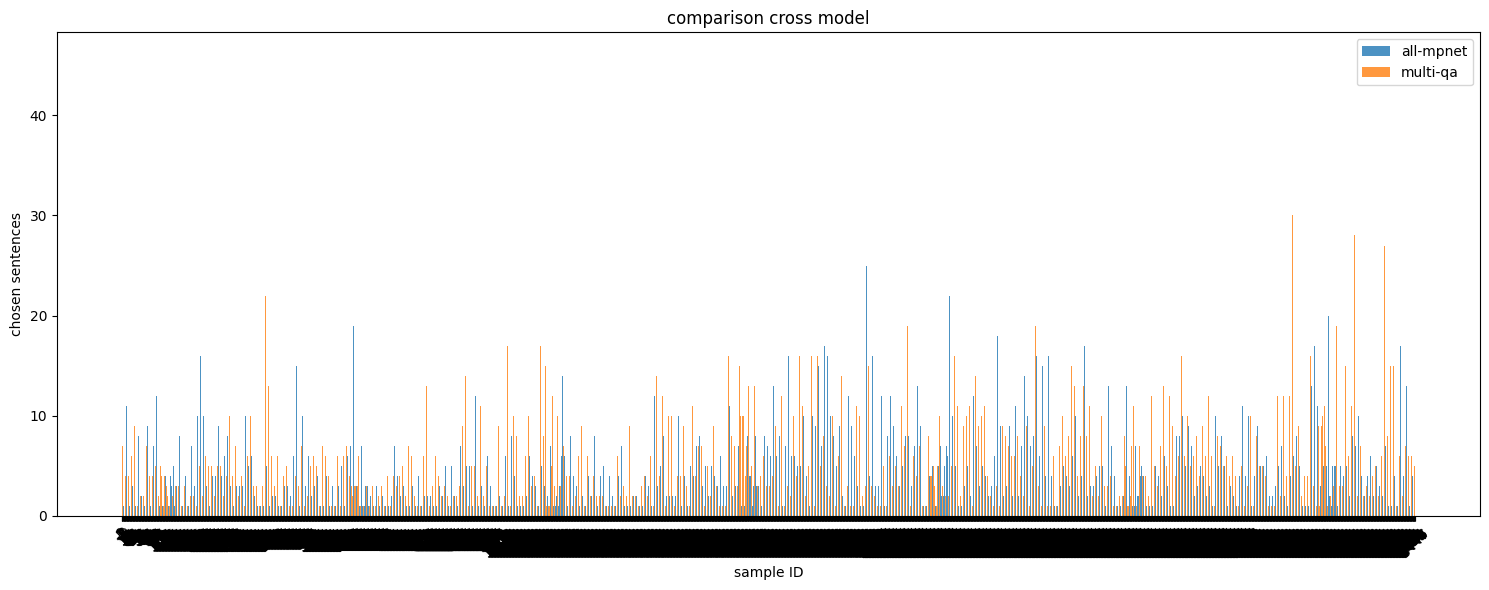

In [ ]:
from google.colab import drive
import json
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt

drive.mount("/content/drive")
base = "/content/drive/MyDrive"

def load_json_file(filepath):
  with open(filepath, 'r', encoding='utf-8') as f:
    return [json.loads(line) for line in f]

all_results = load_json_file(f"{base}/train_results_all.jsonl")
multi_results = load_json_file(f"{base}/train_results_multi_fivenine.jsonl")

print(f"all-mpnet file: {len(all_results)}")
print(f"multi-qa file: {len(multi_results)}")
print("="*80)


def detailed_comparison(all_results, multi_results):
  differences = []
  agreements = []

  for i, (all_item, multi_item) in enumerate(zip(all_results, multi_results)):
    all_sentences = set([s['sentence'] for s in all_item['chosen_sentence']])
    multi_sentences = set([s['sentence'] for s in multi_item['chosen_sentence']])

    common = all_sentences.intersection(multi_sentences)
    only_all = all_sentences - multi_sentences
    only_multi = multi_sentences - all_sentences

    diff_info = {
      'id': all_item['id'],
      'question': all_item['question'],
      'all_count': len(all_sentences),
      'multi_count': len(multi_sentences),
      'common_count': len(common),
      'only_all': list(only_all),
      'only_multi': list(only_multi),
      'all_scores': [s['score'] for s in all_item['chosen_sentence']],
      'multi_scores': [s['score'] for s in multi_item['chosen_sentence']],
        }

    if only_all or only_multi:
      differences.append(diff_info)
    else:
      agreements.append(diff_info)

  print(f"\n Completely identical samples: {len(agreements)}")
  print(f"Different samples: {len(differences)}")
  print(f"Difference ratio: {len(differences)/len(all_results)*100:.1f}%")

  return differences, agreements

differences, agreements = detailed_comparison(all_results, multi_results)

if differences:
  print("\n The top 5 samples with the largest differences:")
  print("-" * 80)

  for diff in sorted(differences, key=lambda x: abs(x['all_count'] - x['multi_count']), reverse=True)[:5]:
    print(f"\nID: {diff['id']}")
    print(f"question: {diff['question']}")
    print(f"all-mpnet: chose {diff['all_count']}, at score: {[round(s,4) for s in diff['all_scores']]}")
    print(f"multi-qa:  chose {diff['multi_count']}, at score: {[round(s,4) for s in diff['multi_scores']]}")
    print(f"same sentences: {diff['common_count']} ")
    if diff['only_all']:
      print(f"  only_all: {diff['only_all']}")
    if diff['only_multi']:
      print(f"  only_multi: {diff['only_multi']}")
    print("-" * 40)


def plot_comparison(all_results, multi_results):
  ids = [item['id'] for item in all_results]
  all_counts = [len(item['chosen_sentence']) for item in all_results]
  multi_counts = [len(item['chosen_sentence']) for item in multi_results]

  plt.figure(figsize=(15, 6))

  x = range(len(ids))
  width = 0.35
  plt.bar([i - width/2 for i in x], all_counts, width, label='all-mpnet', alpha=0.8)
  plt.bar([i + width/2 for i in x], multi_counts, width, label='multi-qa', alpha=0.8)

  plt.xlabel('sample ID')
  plt.ylabel('chosen sentences')
  plt.title('comparison cross model')
  plt.legend()
  plt.xticks(x, ids, rotation=45)
  plt.tight_layout()
  plt.show()
plot_comparison(all_results, multi_results)

In [ ]:
import json
from collections import Counter


def compare(l1, l2):
    return Counter(l1) == Counter(l2)


def load_json_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read().strip()
        if content.startswith('['):
            return json.loads(content)
        else:
            return [json.loads(line) for line in content.splitlines() if line.strip()]


def merge_chosen_sentences(all_data, multi_data):
    merged_dict = {}
    stats = {
        'Completely identical': 0,
        'Same number but different content': 0,
        'Same number with overlapping content': 0,
        'Different number': 0,
        'Total number of samples': len(all_data),
        'Details of differences': []
    }

    for item in all_data:
        item_id = item['id']
        chosen = item.get('chosen_sentence', [])
        all_chosen = [sent['sentence'] for sent in chosen] if chosen else None
        merged_dict[item_id] = {'all_chosen': all_chosen, 'multi_chosen': None, 'final_chosen': []}

    for item in multi_data:
        item_id = item['id']
        chosen = item.get('chosen_sentence', [])
        multi_chosen = [sent['sentence'] for sent in chosen] if chosen else None
        if item_id in merged_dict:
            merged_dict[item_id]['multi_chosen'] = multi_chosen

    for item_id, data in merged_dict.items():
        all_list = data['all_chosen'] or []
        multi_list = data['multi_chosen'] or []

        all_set = set(all_list)
        multi_set = set(multi_list)

        both = [s for s in all_list if s in multi_set]
        only_all = [s for s in all_list if s not in multi_set]
        only_multi = [s for s in multi_list if s not in all_set]
        data['final_chosen'] = both + only_all + only_multi

        if compare(all_list, multi_list):
            diff_type = 'Completely identical'
            stats['Completely identical'] += 1
        elif len(all_list) == len(multi_list) and len(both) == 0:
            diff_type = 'Same number but different content'
            stats['Same number but different content'] += 1
        elif len(all_list) == len(multi_list) and len(both) > 0:
            diff_type = 'Same number with overlapping content'
            stats['Same number with overlapping content'] += 1
        else:
            diff_type = 'Different number'
            stats['Different number'] += 1

        total_count = len(all_list) + len(multi_list)
        overlap_ratio = (len(both) * 2) / total_count if total_count > 0 else 1.0

        stats['Details of differences'].append({
            'id': item_id,
            'type': diff_type,
            'all_count': len(all_list),
            'multi_count': len(multi_list),
            'common_count': len(both),
            'overlap_ratio': round(overlap_ratio, 3),
            'only_all': only_all[:3],
            'only_multi': only_multi[:3]
        })

    stats['Total differences'] = (
        stats['Same number but different content'] +
        stats['Same number with overlapping content'] +
        stats['Different number']
    )
    stats['Difference ratio'] = f"{stats['Total differences'] / stats['Total number of samples'] * 100:.1f}%"

    overlap_ratios = [d['overlap_ratio'] for d in stats['Details of differences']]
    stats['Average overlap ratio'] = round(sum(overlap_ratios) / len(overlap_ratios), 3)

    return merged_dict, stats


def save_json_file(data, filepath):
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def main():

    all_test_results = load_json_file(f"{base}/test_results_all.jsonl")
    multi_test_results = load_json_file(f"{base}/test_results_multi_fivenine.jsonl")

    merged_data, stats = merge_chosen_sentences(all_test_results, multi_test_results)

    save_json_file(merged_data, 'merged_chosen_sentences.json')
    save_json_file(stats, 'comparison_stats.json')


if __name__ == "__main__":
    main()


**Experiment(to check the performance on different models)**

In [ ]:
#### experiment
model = SentenceTransformer("all-mpnet-base-v2")
model2 = SentenceTransformer("multi-qa-mpnet-base-cos-v1")

def calculate(model, question, answer):
  query_embedding = model.encode(question)
  passage_embeddings = model.encode(answer)
  similarity = model.similarity(query_embedding, passage_embeddings)
  similarity_list = similarity[0].tolist()

  return similarity_list

q = ("Why should Americans and why should President Trump believe your statement that Russia did not intervene in the 2016 election, given the evidence that U.S. intelligence agencies have provided?")
a = (["Well, I'm going to let the President answer the second part of that question But, as you know, the whole concept of that came up perhaps a little bit before, but it came out as a reason why the Democrats lost an election, which, frankly, they should have been able to win, because the electoral college is much more advantageous for Democrats, as you know, than it is to Republicans", "We won the electoral college by a lot—306 to 223, I believe And that was a well-fought—that was a well-fought battle We did a great jobAnd, frankly, I'm going to let the President speak to the second part of your question But just to say it one time again, and I say it all the time: There was no collusion I didn't know the President There was nobody to collude with", "There was no collusion with the campaign And every time you hear all of these—you know, 12 and 14—it's stuff that has nothing to do—and frankly, they admit, these are not people involved in the campaign", "But to the average reader out there, they're saying, Well, maybe that does It doesn't", "And even the people involved, some perhaps told mis-stories or, though in one case, the FBI said there was no lie There was no lie Somebody else said there wasWe ran a brilliant campaign, and that's why I'm President", 'Thank you As to who is to be believed and to who is not to be believed, you can trust no one, if you take this Where did you get this idea that President Trump trusts me or I trust him?', 'He defends the interests of the United States of America, and I do defend the interests of the Russian FederationWe do have interests that are common', 'We are looking for points of contact', 'There are issues where our postures diverge, and we are looking for ways to reconcile our differences; how to make our effort more meaningfulWe should not proceed from the immediate political interests that guide certain political powers in our countries We should be guided by facts', 'Could you name a single fact that would definitively prove the collusion?', "This is utter nonsense, just like the President recently mentionedYes, the public at large in the United States had a certain perceived opinion of the candidates during the campaign, but there's nothing particularly extraordinary about it", "That's the usual thing President Trump, when he was a candidate, he mentioned the need to restore the Russia-US relationship, and it's clear that a certain part of American society felt sympathetic about it, and different people could express their sympathy in different ways", "But isn't that natural?", "Isn't it natural to be sympathetic towards a person who is willing to restore the relationship with our country, who wants to work with us?We heard the accusations about the Concord country", "Well, as far as I know, this company hired American lawyers And the accusations doesn't—doesn't have a fighting chance in the American courts", "So there's no evidence when it comes to the actual facts So we have to be guided by facts and not by rumorsNow", ", let's get back to the issue of these 12 alleged intelligence officers of Russia I don't know the full extent of the situation, but the President Trump mentioned this issue, and I will look into", 'itSo far, I can say the following, the things that—off the top of my head: We have an acting—an existing agreement between the United States of America and the Russian Federation, an existing treaty that dates back to 1999, the Mutual Assistance on Criminal Cases', 'This treaty is in full effect It works quite efficientlyOn average, we initiate about a hundred, hundred and fifty criminal cases upon request from foreign states', 'For instance, the last year, there was one extradition case, upon the request, sent by the United States', 'So this treaty has specific legal proceduresWe', 'can offer that the appropriate commission headed by Special Attorney Mueller—he can use this treaty as a solid foundation, and send a formal, an official request to us so that we would interrogate—we would hold the questioning of these individuals who he believes are privy to some crimes And our law enforcement are perfectly able to do this questioning and send the appropriate materials to the United StatesMoreover, we can meet you halfway; we can make another step', 'We can actually permit official representatives of the United States, including the members of this very commission headed by Mr Mueller—we can let them into the country and they will be present at this questioningBut in this case, there is another condition This kind of effort should be a mutual one', 'Then we would expect that the Americans would reciprocate, and they would question officials, including the officers of law enforcement and intelligence services of the United States whom we believe are—who have something to do with illegal actions on the territory of Russia,', 'and', "we have to request the presence of our law enforcementFor instance, we can bring up the—Mr Browder in this particular case Business associates of Mr Browder have earned over $1½ billion in Russia They never paid any taxes, neither in Russia nor in the United States, and yet the money escaped the country They were transferred to the United States They sent a huge amount of money—400 million—as a contribution to the campaign of Hillary Clinton Well, that's their personal case It might have been legal, the contribution itself, but the way the money was earned was illegalSo we have a solid reason to believe that some intelligence officers accompanied and guided these transactions So we have an interest of questioning them We can—that could be a first step, and we can also extend it Options abound, and they all can be found in an appropriate legal framework"])

q1 = (" Is the $25 billion a red line for you?")
a1 = ( ["I have no red line, unlike President Obama.", "I just want great border security.", "Okay?"])

q2 = ("What does permanent or enduring presence mean in concrete terms?")
a2 = ( ["I understand it in the follow way: President Donald Trump and myself are implementing a very calm but consistent policy in terms of security.", "The presence of the United States in Poland—the military presence—the presence of U.S. troops, which today is about 4,500 troops present on a permanent basis.", "In other words, it is a rotational presence but it is back-to-back presence.", "So there is no moment where there are no American troops in the territory of Poland.", "And today we signed a document and further cooperation: a Joint Declaration on Defense Cooperation Regarding the United States Force Posture in the Republic of Poland.", "This is of a breakthrough character because it moves us to another era.", "So far, we can say that the Americans were testing the situation in Poland: how it looks, how it feels; what about logistics; whether it is possible to stay in Poland and to successfully attain the goals and implement the tasks of defensive nature.", "I think that the commanders of U.S. Army are convinced that this is simply possible.", "And today, the documents speaks about this enduring presence, the presence which is a fact and which will stay there.", "It is a rotational presence as it is because this is most beneficial from today's perspective to train soldiers through rotational presence.", "By having rotational presence, more soldiers can come to a country, be present there, look at a culture and the condition in place in a given country.", "So this is beneficial for this barely understood—a development of the Armed Forces.", "Therefore, this is an enduring presence.", "However, it is implementing this particular way.", "And we hope it's going to develop 1,000 troops, mentioned by President Trump today, which is also—the numbers stipulated in the agreement signed today is very differentiated.", "It is not one single unit.", "We are talking about special operation forces.", "We are talking about logistics component.", "We are also talking about the already-mentioned division headquarters.", "So there is a multitude of forums in which the United States is going to be gradually ever-more present in our territory, from the military standpoint.", "And this will encompass different fields of cooperation.", "So we're not talking about just one single beat, but we're talking about a more comprehensive cooperation.", "We're talking about logistics health protection for soldiers and a number of other elements happening.", "Please remember that right now there is this missile defense facility being built in Redzikowo.", "So, talking about the elements of Polish-American cooperation, there are more and more of these elements, and the number is growing.", "I'm very happy with that.", "Thank you very much.", "Let's see, who do I like?", "Nobody.", "That's the end.", "Go ahead.", "Yes."])

q3 = ( " Position on trade deal with the U.K.")
a3 = (["Okay.", "Excellent questions, Roberta.", "She doesn't sound Canadian.", "That was pretty mean.", "Canadians are a little more subtle.", "I'm actually going to help out my friends a little bit on your last question, even though it wasn't directed at me, and just say, when I visit other countries, it's not my job to comment on candidates in the middle of a race, just because they may end up winning.", "And the relationship between governments tend to transcend whoever is in power at any given time.", "So it's a tough question.", "It's—I'm not saying they shouldn't answer it, I'm just—I'm helping them out a little bit.", "Because there's no doubt that when I visit countries, there are times where I've got preferences, but I'd rarely express them.", "With respect to Brexit, first of all, I think you've seen the markets settle down a little bit over the last couple of days.", "I didn't follow the markets today.", "But we're monitoring very carefully whether there's any systemic strains on the system.", "And so far, what you've seen is reactions in the market, stock prices, currencies.", "But I think the preparations that were done by central banks and Finance Ministers, our Treasury Secretary, indicate the degree to which the global economy in the short run will hold steady.", "I think there are some genuine longer term concerns about global growth if in fact Brexit goes through and that freezes the possibilities of investment in Great Britain or in Europe as a whole.", "At a time when global growth rates were weak already, this doesn't help.", "And so when we attend the G-20 summit in China later this year, one of the major topics—which is something that I've continually advocated for during the 7½ years that I've been President—is we all have to look at what we can do to boost global demand: whether it's the United States adopting a more robust budget for infrastructure improvements and fixing water systems in Flint, Michigan, or repairing airports that are not as efficient as they should be or rebuilding our power grid so that it can take advantage of clean energy; whether it's Germany, a country with a surplus, doing more in terms of spending, or Europe as a whole lifting some of the austerity constraints that have been placed on them; whether it's China shifting to a more consumer-based, domestic-based growth strategy as opposed to trying to export its way out of problems.", "There are going to be a whole host of measures that all of us can take to fortify the global economy, and that should be a top priority of ours.", "With respect to the actual Brexit negotiations, my main message to David Cameron, Angela Merkel and others is: Everybody should catch their breath, come up with a plan and a process that is orderly, that's transparent, that people understand, and then proceed, understanding that both sides have a stake in getting this right.", "And I think that that will be a difficult, challenging process, but it does not need to be a panicky process.", "I think it can be a steady, sensible process.", "Obviously, leadership issues in Great Britain will need to be resolved for it to move as crisply and as effectively as it needs to, but that—I think that's recognized, and that should happen fairly quickly.", "And I know that, speaking with Chancellor Merkel, that her interest is not in retribution, her interest is in making sure that the process works.", "And I have a lot of confidence in people being able to do that.", "And we will help in any way that we can to facilitate that.", "And then, the last part of your question is with respect to the U.K. and any trade agreement with the United States.", "Frankly, we will be the least of their problems right now, because their first order of business is going to be to address the market where they sell half their goods, which is Europe.", "And these things are not easily negotiated, particularly because we've been spending our time trying to negotiate with the European Union.", "And so to suddenly go off on another track will be challenging.", "But I think their first and primary concern is going to be to try to figure out how they interact with the European Union and the European market if in fact—and when in fact—they leave.", "I have emphasized throughout, though, that the special relationship that we have with Great Britain does not change; that the ties of affection and family and language and institutions and culture and the business relationships that exist, those are so deep and so long lasting—the cooperation we have on security issues and on global challenges, those are so fundamental—that our relationship with the U.K. fundamentally doesn't change.", "We are concerned that their absence from the European Union and the potential disruptions within Europe make it harder for us to solve some of the other challenges that have to be solved.", "[.] One of the things that's easy to forget amid the inflated rhetoric of an election campaign is that the relationship between our three countries goes far deeper than any individual leaders.", "And if the three of us get along, it's not just because we're aligned in many different values and priorities, it is very much because we serve citizens who are, they themselves, tremendously aligned in terms of priorities, in terms of hopes and dreams, in terms of desire for success and ways to reach it.", "So when you look at the level of integration, of our supply chains, of our markets, of the flow back and forward across borders of goods, of people, and the tremendous benefits that have come from proximity and strong relationships to individual citizens across this continent, it's essential that we understand that regardless of electoral rhetoric, Canada, the United States, and Mexico will continue to have tremendously close relationships economically, culturally, socially, familialy, historically, and towards the future.", "So as I've said many times, and I'll say again, I look forward to working with whomever the American people choose to elect as their President in November.", "I know that we will always be able to find shared priorities and challenges that we want to work together to overcome.", "And I know that our commitment to doing what's right and what's best for our citizens will lead us to much more alignment than differentiation.", "Roberta, I'll go straight to the point to describe the stand of my administration and my own very personal point of view.", "I've said it, and I'll say it again: My Government will respect fully the domestic electoral process in the United States.", "I don't think I've said anything different from what I'm stating once again here.", "What I have said is that today—and I did not make reference to a specific place—my words reinforce what I believe.", "I believe that in this global scenario—and I'll use President Obama's words, and as he said, he gave us a hand to address this question—we are facing a global reality.", "We have a populist world, an interconnected world with its own challenges.", "What I have said is that, in the world we're living, in different places, we have political leaders, political stakeholders that use demagoguery and have the populistic slogans that want to eliminate and destroy what has been built, what has taken decades to build to go back to problems of the past.", "And yes, it is true, all the benefits have not reached society as we whole.", "That is true.", "But those leaderships, those political actors, by using populism and demagoguery, they choose the easiest way to solve the challenges of today's world.", "And things are not that simplistic.", "It's not as easy as that.", "To lead a country, to take on a responsibility to rule a country, it goes beyond giving the easiest answer.", "It is complex and it is difficult to lead a country.", "And I just said it: What we have reached so far—the level of development, the level of well-being that we have in the world—without a doubt makes contrast with what the situation that we lived 30 years back.", "Never before a global society—or the societies, at least, of our three countries—had lived the level of development and well-being that we enjoy today.", "Never before had our countries had a high life expectancy as we have today.", "Never before had we had the opportunity to have access to the knowledge of the world as fast and as easy as we do today.", "Never before were in such a level of connection between society and the possibility of having access to any product from any corner of the world as we do today.", "And that was built throughout the years by using the model based on openness, free trade, trade agreements.", "And the biggest challenge today is to make sure that those benefits reach out to every single citizen.", "But the solution proposed by some is not by destroying what we have been built, it is not taking a different route to choose the road towards isolationism and destruction.", "What we need to do is to keep up the pace towards development.", "And when I said that, I mentioned that most of what some people say, it is very similar that in the past—and President Obama already said it, even years back—but in the past, some leaders addressed their societies in those terms.", "Hitler and Mussolini did that.", "And the outcome, it's clear to everyone: It resulted in devastation, and it turned out to be a tragedy for mankind.", "And we saw it last century.", "That was my message when I made reference to this event.", "My message was about to value what we have and also to be aware of the road that we need to walk still.", "But that's the benefit that we're looking forward to: take the benefits to our societies.", "[ spoke in English as follows.", "]", "[Inaudible]—last question.[.]The question will be from Mr. Philippe-Vincent Foisy of Cogeco News.", "[.", "]"])

print(calculate(model, q1, a1))
print(calculate(model2, q1, a1))

print(calculate(model, q2, a2))
print(calculate(model2, q2, a2))

print(calculate(model, q3, a3))
print(calculate(model2, q3, a3))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[0.4123362898826599, 0.36727938055992126, 0.13278663158416748]
[0.39092522859573364, 0.2605733275413513, 0.12046009302139282]
[0.2785259187221527, 0.37565332651138306, 0.4060467779636383, 0.16414988040924072, 0.11493831127882004, 0.10469929128885269, 0.20833517611026764, 0.0141062643378973, 0.6396611928939819, 0.3460739850997925, 0.34860891103744507, 0.15558581054210663, 0.6924320459365845, 0.09569218009710312, 0.11800569295883179, 0.12535202503204346, 0.11686666309833527, 0.18295833468437195, 0.18762043118476868, 0.2315644770860672, 0.198333740234375, 0.08100180327892303, 0.1277650147676468, 0.0799875408411026, 0.1841239631175995, 0.020258532837033272, 0.06976119428873062, -0.0530112199485302, -0.06732118874788284, 0.061575159430503845, 0.024775434285402298, 0.11105389893054962]
[0.23465192317962646, 0.29107487201690674, 0.2579893469810486, 0.09168736636638641, -0.0015000160783529282, 0.08499477803707123, 0.11706818640232086, -0.0014713271521031857, 0.5828546285629272, 0.2545552849769

In [ ]:
#### experiment
model = SentenceTransformer("all-mpnet-base-v2")
model2 = SentenceTransformer("multi-qa-mpnet-base-cos-v1")

def calculate(model):
  query_embedding = model.encode("What is your perspective on the role of fiscal policy in mitigating income inequality?")
  passage_embeddings = model.encode(["My perspective on fiscal policy and its role in mitigating income inequality is that fiscal policy involves government spending and taxation, and income inequality refers to the unequal distribution of income across society.",
                    "I believe that how a government manages its treasury and allocates public funds to support disadvantaged groups can substantially narrow the economic divide between rich and poor citizens.",
                    "My view is that fiscal policy, through progressive taxation and targeted social spending, can effectively mitigate income inequality by redistributing wealth from higher to lower income brackets.",
                    "The weather today is quite pleasant, and I'm considering what to have for lunch later. Perhaps some sushi would be nice, or maybe a sandwich."])
  similarity = model.similarity(query_embedding, passage_embeddings)
  return similarity

print(calculate(model))
print(calculate(model2))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/multi-qa-mpnet-base-cos-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[0.8284, 0.5839, 0.8113, 0.0401]])
tensor([[ 0.8651,  0.6901,  0.8394, -0.0278]])


In [ ]:
from sentence_transformers import CrossEncoder
import numpy as np

# trial
'''models = [
    'cross-encoder/ms-marco-MiniLM-L6-v2',     # Information retrieval
    #'cross-encoder/nli-deberta-v3-base',        # Natural Language Inference
    'cross-encoder/qnli-electra-base',          # QNLI mission
    #'cross-encoder/stsb-roberta-base',          # Semantic text similarity
    #'cross-encoder/quora-distilroberta-base'     # Problem matching
]'''

q = ("Why should Americans and why should President Trump believe your statement that Russia did not intervene in the 2016 election, given the evidence that U.S. intelligence agencies have provided?")
a = (["Well, I'm going to let the President answer the second part of that question But, as you know, the whole concept of that came up perhaps a little bit before, but it came out as a reason why the Democrats lost an election, which, frankly, they should have been able to win, because the electoral college is much more advantageous for Democrats, as you know, than it is to Republicans", "We won the electoral college by a lot—306 to 223, I believe And that was a well-fought—that was a well-fought battle We did a great jobAnd, frankly, I'm going to let the President speak to the second part of your question But just to say it one time again, and I say it all the time: There was no collusion I didn't know the President There was nobody to collude with", "There was no collusion with the campaign And every time you hear all of these—you know, 12 and 14—it's stuff that has nothing to do—and frankly, they admit, these are not people involved in the campaign", "But to the average reader out there, they're saying, Well, maybe that does It doesn't", "And even the people involved, some perhaps told mis-stories or, though in one case, the FBI said there was no lie There was no lie Somebody else said there wasWe ran a brilliant campaign, and that's why I'm President", 'Thank you As to who is to be believed and to who is not to be believed, you can trust no one, if you take this Where did you get this idea that President Trump trusts me or I trust him?', 'He defends the interests of the United States of America, and I do defend the interests of the Russian FederationWe do have interests that are common', 'We are looking for points of contact', 'There are issues where our postures diverge, and we are looking for ways to reconcile our differences; how to make our effort more meaningfulWe should not proceed from the immediate political interests that guide certain political powers in our countries We should be guided by facts', 'Could you name a single fact that would definitively prove the collusion?', "This is utter nonsense, just like the President recently mentionedYes, the public at large in the United States had a certain perceived opinion of the candidates during the campaign, but there's nothing particularly extraordinary about it", "That's the usual thing President Trump, when he was a candidate, he mentioned the need to restore the Russia-US relationship, and it's clear that a certain part of American society felt sympathetic about it, and different people could express their sympathy in different ways", "But isn't that natural?", "Isn't it natural to be sympathetic towards a person who is willing to restore the relationship with our country, who wants to work with us?We heard the accusations about the Concord country", "Well, as far as I know, this company hired American lawyers And the accusations doesn't—doesn't have a fighting chance in the American courts", "So there's no evidence when it comes to the actual facts So we have to be guided by facts and not by rumorsNow", ", let's get back to the issue of these 12 alleged intelligence officers of Russia I don't know the full extent of the situation, but the President Trump mentioned this issue, and I will look into", 'itSo far, I can say the following, the things that—off the top of my head: We have an acting—an existing agreement between the United States of America and the Russian Federation, an existing treaty that dates back to 1999, the Mutual Assistance on Criminal Cases', 'This treaty is in full effect It works quite efficientlyOn average, we initiate about a hundred, hundred and fifty criminal cases upon request from foreign states', 'For instance, the last year, there was one extradition case, upon the request, sent by the United States', 'So this treaty has specific legal proceduresWe', 'can offer that the appropriate commission headed by Special Attorney Mueller—he can use this treaty as a solid foundation, and send a formal, an official request to us so that we would interrogate—we would hold the questioning of these individuals who he believes are privy to some crimes And our law enforcement are perfectly able to do this questioning and send the appropriate materials to the United StatesMoreover, we can meet you halfway; we can make another step', 'We can actually permit official representatives of the United States, including the members of this very commission headed by Mr Mueller—we can let them into the country and they will be present at this questioningBut in this case, there is another condition This kind of effort should be a mutual one', 'Then we would expect that the Americans would reciprocate, and they would question officials, including the officers of law enforcement and intelligence services of the United States whom we believe are—who have something to do with illegal actions on the territory of Russia,', 'and', "we have to request the presence of our law enforcementFor instance, we can bring up the—Mr Browder in this particular case Business associates of Mr Browder have earned over $1½ billion in Russia They never paid any taxes, neither in Russia nor in the United States, and yet the money escaped the country They were transferred to the United States They sent a huge amount of money—400 million—as a contribution to the campaign of Hillary Clinton Well, that's their personal case It might have been legal, the contribution itself, but the way the money was earned was illegalSo we have a solid reason to believe that some intelligence officers accompanied and guided these transactions So we have an interest of questioning them We can—that could be a first step, and we can also extend it Options abound, and they all can be found in an appropriate legal framework"])

q1 = (" Is the $25 billion a red line for you?")
a1 = ( ["I have no red line, unlike President Obama.", "I just want great border security.", "Okay?"])

q2 = ("What does permanent or enduring presence mean in concrete terms?")
a2 = ( ["I understand it in the follow way: President Donald Trump and myself are implementing a very calm but consistent policy in terms of security.", "The presence of the United States in Poland—the military presence—the presence of U.S. troops, which today is about 4,500 troops present on a permanent basis.", "In other words, it is a rotational presence but it is back-to-back presence.", "So there is no moment where there are no American troops in the territory of Poland.", "And today we signed a document and further cooperation: a Joint Declaration on Defense Cooperation Regarding the United States Force Posture in the Republic of Poland.", "This is of a breakthrough character because it moves us to another era.", "So far, we can say that the Americans were testing the situation in Poland: how it looks, how it feels; what about logistics; whether it is possible to stay in Poland and to successfully attain the goals and implement the tasks of defensive nature.", "I think that the commanders of U.S. Army are convinced that this is simply possible.", "And today, the documents speaks about this enduring presence, the presence which is a fact and which will stay there.", "It is a rotational presence as it is because this is most beneficial from today's perspective to train soldiers through rotational presence.", "By having rotational presence, more soldiers can come to a country, be present there, look at a culture and the condition in place in a given country.", "So this is beneficial for this barely understood—a development of the Armed Forces.", "Therefore, this is an enduring presence.", "However, it is implementing this particular way.", "And we hope it's going to develop 1,000 troops, mentioned by President Trump today, which is also—the numbers stipulated in the agreement signed today is very differentiated.", "It is not one single unit.", "We are talking about special operation forces.", "We are talking about logistics component.", "We are also talking about the already-mentioned division headquarters.", "So there is a multitude of forums in which the United States is going to be gradually ever-more present in our territory, from the military standpoint.", "And this will encompass different fields of cooperation.", "So we're not talking about just one single beat, but we're talking about a more comprehensive cooperation.", "We're talking about logistics health protection for soldiers and a number of other elements happening.", "Please remember that right now there is this missile defense facility being built in Redzikowo.", "So, talking about the elements of Polish-American cooperation, there are more and more of these elements, and the number is growing.", "I'm very happy with that.", "Thank you very much.", "Let's see, who do I like?", "Nobody.", "That's the end.", "Go ahead.", "Yes."])

q3 = ( " Position on trade deal with the U.K.")
a3 = (["Okay.", "Excellent questions, Roberta.", "She doesn't sound Canadian.", "That was pretty mean.", "Canadians are a little more subtle.", "I'm actually going to help out my friends a little bit on your last question, even though it wasn't directed at me, and just say, when I visit other countries, it's not my job to comment on candidates in the middle of a race, just because they may end up winning.", "And the relationship between governments tend to transcend whoever is in power at any given time.", "So it's a tough question.", "It's—I'm not saying they shouldn't answer it, I'm just—I'm helping them out a little bit.", "Because there's no doubt that when I visit countries, there are times where I've got preferences, but I'd rarely express them.", "With respect to Brexit, first of all, I think you've seen the markets settle down a little bit over the last couple of days.", "I didn't follow the markets today.", "But we're monitoring very carefully whether there's any systemic strains on the system.", "And so far, what you've seen is reactions in the market, stock prices, currencies.", "But I think the preparations that were done by central banks and Finance Ministers, our Treasury Secretary, indicate the degree to which the global economy in the short run will hold steady.", "I think there are some genuine longer term concerns about global growth if in fact Brexit goes through and that freezes the possibilities of investment in Great Britain or in Europe as a whole.", "At a time when global growth rates were weak already, this doesn't help.", "And so when we attend the G-20 summit in China later this year, one of the major topics—which is something that I've continually advocated for during the 7½ years that I've been President—is we all have to look at what we can do to boost global demand: whether it's the United States adopting a more robust budget for infrastructure improvements and fixing water systems in Flint, Michigan, or repairing airports that are not as efficient as they should be or rebuilding our power grid so that it can take advantage of clean energy; whether it's Germany, a country with a surplus, doing more in terms of spending, or Europe as a whole lifting some of the austerity constraints that have been placed on them; whether it's China shifting to a more consumer-based, domestic-based growth strategy as opposed to trying to export its way out of problems.", "There are going to be a whole host of measures that all of us can take to fortify the global economy, and that should be a top priority of ours.", "With respect to the actual Brexit negotiations, my main message to David Cameron, Angela Merkel and others is: Everybody should catch their breath, come up with a plan and a process that is orderly, that's transparent, that people understand, and then proceed, understanding that both sides have a stake in getting this right.", "And I think that that will be a difficult, challenging process, but it does not need to be a panicky process.", "I think it can be a steady, sensible process.", "Obviously, leadership issues in Great Britain will need to be resolved for it to move as crisply and as effectively as it needs to, but that—I think that's recognized, and that should happen fairly quickly.", "And I know that, speaking with Chancellor Merkel, that her interest is not in retribution, her interest is in making sure that the process works.", "And I have a lot of confidence in people being able to do that.", "And we will help in any way that we can to facilitate that.", "And then, the last part of your question is with respect to the U.K. and any trade agreement with the United States.", "Frankly, we will be the least of their problems right now, because their first order of business is going to be to address the market where they sell half their goods, which is Europe.", "And these things are not easily negotiated, particularly because we've been spending our time trying to negotiate with the European Union.", "And so to suddenly go off on another track will be challenging.", "But I think their first and primary concern is going to be to try to figure out how they interact with the European Union and the European market if in fact—and when in fact—they leave.", "I have emphasized throughout, though, that the special relationship that we have with Great Britain does not change; that the ties of affection and family and language and institutions and culture and the business relationships that exist, those are so deep and so long lasting—the cooperation we have on security issues and on global challenges, those are so fundamental—that our relationship with the U.K. fundamentally doesn't change.", "We are concerned that their absence from the European Union and the potential disruptions within Europe make it harder for us to solve some of the other challenges that have to be solved.", "[.] One of the things that's easy to forget amid the inflated rhetoric of an election campaign is that the relationship between our three countries goes far deeper than any individual leaders.", "And if the three of us get along, it's not just because we're aligned in many different values and priorities, it is very much because we serve citizens who are, they themselves, tremendously aligned in terms of priorities, in terms of hopes and dreams, in terms of desire for success and ways to reach it.", "So when you look at the level of integration, of our supply chains, of our markets, of the flow back and forward across borders of goods, of people, and the tremendous benefits that have come from proximity and strong relationships to individual citizens across this continent, it's essential that we understand that regardless of electoral rhetoric, Canada, the United States, and Mexico will continue to have tremendously close relationships economically, culturally, socially, familialy, historically, and towards the future.", "So as I've said many times, and I'll say again, I look forward to working with whomever the American people choose to elect as their President in November.", "I know that we will always be able to find shared priorities and challenges that we want to work together to overcome.", "And I know that our commitment to doing what's right and what's best for our citizens will lead us to much more alignment than differentiation.", "Roberta, I'll go straight to the point to describe the stand of my administration and my own very personal point of view.", "I've said it, and I'll say it again: My Government will respect fully the domestic electoral process in the United States.", "I don't think I've said anything different from what I'm stating once again here.", "What I have said is that today—and I did not make reference to a specific place—my words reinforce what I believe.", "I believe that in this global scenario—and I'll use President Obama's words, and as he said, he gave us a hand to address this question—we are facing a global reality.", "We have a populist world, an interconnected world with its own challenges.", "What I have said is that, in the world we're living, in different places, we have political leaders, political stakeholders that use demagoguery and have the populistic slogans that want to eliminate and destroy what has been built, what has taken decades to build to go back to problems of the past.", "And yes, it is true, all the benefits have not reached society as we whole.", "That is true.", "But those leaderships, those political actors, by using populism and demagoguery, they choose the easiest way to solve the challenges of today's world.", "And things are not that simplistic.", "It's not as easy as that.", "To lead a country, to take on a responsibility to rule a country, it goes beyond giving the easiest answer.", "It is complex and it is difficult to lead a country.", "And I just said it: What we have reached so far—the level of development, the level of well-being that we have in the world—without a doubt makes contrast with what the situation that we lived 30 years back.", "Never before a global society—or the societies, at least, of our three countries—had lived the level of development and well-being that we enjoy today.", "Never before had our countries had a high life expectancy as we have today.", "Never before had we had the opportunity to have access to the knowledge of the world as fast and as easy as we do today.", "Never before were in such a level of connection between society and the possibility of having access to any product from any corner of the world as we do today.", "And that was built throughout the years by using the model based on openness, free trade, trade agreements.", "And the biggest challenge today is to make sure that those benefits reach out to every single citizen.", "But the solution proposed by some is not by destroying what we have been built, it is not taking a different route to choose the road towards isolationism and destruction.", "What we need to do is to keep up the pace towards development.", "And when I said that, I mentioned that most of what some people say, it is very similar that in the past—and President Obama already said it, even years back—but in the past, some leaders addressed their societies in those terms.", "Hitler and Mussolini did that.", "And the outcome, it's clear to everyone: It resulted in devastation, and it turned out to be a tragedy for mankind.", "And we saw it last century.", "That was my message when I made reference to this event.", "My message was about to value what we have and also to be aware of the road that we need to walk still.", "But that's the benefit that we're looking forward to: take the benefits to our societies.", "[ spoke in English as follows.", "]", "[Inaudible]—last question.[.]The question will be from Mr. Philippe-Vincent Foisy of Cogeco News.", "[.", "]"])

model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L6-v2')
model2 = CrossEncoder('cross-encoder/qnli-electra-base')

def calculate(model, q, a):
  scores = model.predict([(q, a[i]) for i in range(len(a))])
  return scores

print(calculate(model, q1, a1))
print(calculate(model2, q1, a1))

print(calculate(model, q2, a2))
print(calculate(model2, q2, a2))

print(calculate(model, q3, a3))
print(calculate(model2, q3, a3))



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: cross-encoder/qnli-electra-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
electra.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[ -4.3266764 -11.186118   -9.590242 ]
[0.9968334  0.00271567 0.99281305]
[-11.394666   -6.1896343  -4.5350175 -11.392892  -11.374408  -11.03964
 -11.430916  -11.291363    3.1173322  -6.5601306  -8.776473  -11.239332
   3.3903933 -10.289691  -11.448149  -10.223405  -11.2835    -11.160773
 -11.320952  -11.213     -10.97926   -11.315029  -11.422204  -11.45023
 -11.36358   -10.64958   -10.614172  -10.786171   -9.650768   -9.721257
 -10.468388   -9.001266 ]
[1.2359804e-03 4.3457836e-01 8.7806405e-03 1.5261041e-02 7.0168804e-03
 1.7961721e-03 2.7627607e-03 1.0897736e-03 9.9092495e-01 8.9386577e-04
 1.3121326e-03 8.4030315e-02 2.5605892e-03 2.4378709e-03 3.9400696e-03
 4.6363482e-03 8.0584890e-01 9.5349199e-01 3.7965835e-03 1.8431662e-03
 4.1095079e-03 9.6053593e-03 2.4004517e-02 1.0079747e-03 4.8124171e-03
 3.3852677e-03 2.8050961e-02 1.0029242e-03 9.7749388e-01 5.3385866e-01
 1.2483179e-02 6.9894874e-01]
[ -9.411572   -10.921572   -11.231763   -10.261522   -11.199218
 -11.3743725  -11.35339

In [ ]:
from sentence_transformers import SentenceTransformer, CrossEncoder

# bi-encoder
model = SentenceTransformer("all-mpnet-base-v2")
print(f"all-mpnet-base-v2 max-len: {model.get_max_seq_length()}")


model2 = SentenceTransformer("multi-qa-mpnet-base-cos-v1")
print(f"multi-qa-mpnet-base-cos-v1 max-len: {model2.get_max_seq_length()}")

# cross-encoder
msmarco_model = CrossEncoder('cross-encoder/ms-marco-MiniLM-L6-v2')
print(f"MS-MARCO model tokenizer max-len: {msmarco_model.tokenizer.model_max_length}")

qnli_model = CrossEncoder('cross-encoder/qnli-electra-base')
print(f"QNLI model tokenizer max-len: {qnli_model.tokenizer.model_max_length}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

QNLI model tokenizer max-len: 512
